# 1. Initial EDA Dashboard — Employee Mental Health & Burnout
General exploratory data analysis of the dataset: dimensions, data types, null values, distributions, and basic relationships.

## 1.1. Data Loading and Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("tech_mental_health_burnout.csv")
print(f"Dataset loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded with 150,000 rows and 25 columns.


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


## 1.2. Data Types and Null Values

In [2]:
# Summary of types and nulls
info_df = pd.DataFrame({
    'Type': df.dtypes,
    'Nulls': df.isnull().sum(),
    '% Nulls': (df.isnull().sum() / len(df) * 100).round(2),
    'Uniques': df.nunique()
})
print(info_df.to_string())

                            Type  Nulls  % Nulls  Uniques
age                        int64      0      0.0       33
gender                    object      0      0.0        3
job_role                  object      0      0.0        8
experience_years         float64      0      0.0      172
company_size              object      0      0.0        4
work_mode                 object      0      0.0        3
work_hours_per_week      float64      0      0.0       52
overtime_hours           float64      0      0.0       25
meetings_per_day         float64      0      0.0       13
deadlines_missed           int64      0      0.0        6
job_satisfaction         float64      0      0.0       91
manager_support          float64      0      0.0       91
work_life_balance        float64      0      0.0       91
sleep_hours              float64      0      0.0       71
physical_activity_days     int64      0      0.0        8
screen_time_hours        float64      0      0.0      127
caffeine_intak

In [3]:
# Null values visualization
nulls = df.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)

if len(nulls) > 0:
    plt.figure(figsize=(8, 4))
    nulls.plot(kind='bar', color='steelblue', edgecolor='white')
    plt.title('Columns with null values')
    plt.ylabel('Null count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No null values in the dataset.")

No null values in the dataset.


## 1.3. Descriptive Statistics

In [4]:
df.describe().round(2)

,age,experience_years,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,job_satisfaction,manager_support,work_life_balance,sleep_hours,physical_activity_days,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,seeks_professional_help
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.0,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,150000.0
mean,38.03,5.06,47.01,6.13,4.01,1.28,5.50,5.50,5.02,6.50,2.60,8.00,2.1,5.50,0.25,5.79,4.52,3.10,2.11,0.1
std,9.51,2.88,7.89,3.78,1.98,1.43,1.96,1.96,1.95,1.19,1.81,1.99,1.3,1.96,0.43,1.33,1.20,1.19,1.11,0.3
min,22.00,0.00,30.00,0.00,0.00,0.00,1.00,1.00,1.00,3.00,0.00,3.00,0.0,1.00,0.00,1.00,1.00,1.00,1.00,0.0
25%,30.00,3.00,42.00,3.00,3.00,0.00,4.20,4.10,3.70,5.70,1.00,6.70,1.0,4.20,0.00,4.90,3.70,2.20,1.00,0.0
50%,38.00,5.00,47.00,6.00,4.00,1.00,5.50,5.50,5.00,6.50,2.00,8.00,2.0,5.50,0.00,5.80,4.50,3.10,1.90,0.0
75%,46.00,7.00,52.00,9.00,5.00,2.00,6.90,6.80,6.40,7.30,4.00,9.30,3.0,6.80,1.00,6.70,5.30,3.90,2.80,0.0
max,54.00,18.50,84.00,24.00,12.00,5.00,10.00,10.00,10.00,10.00,7.00,16.00,5.0,10.00,1.00,10.00,9.60,8.10,8.10,1.0


## 1.4. Categorical Variables Distributions

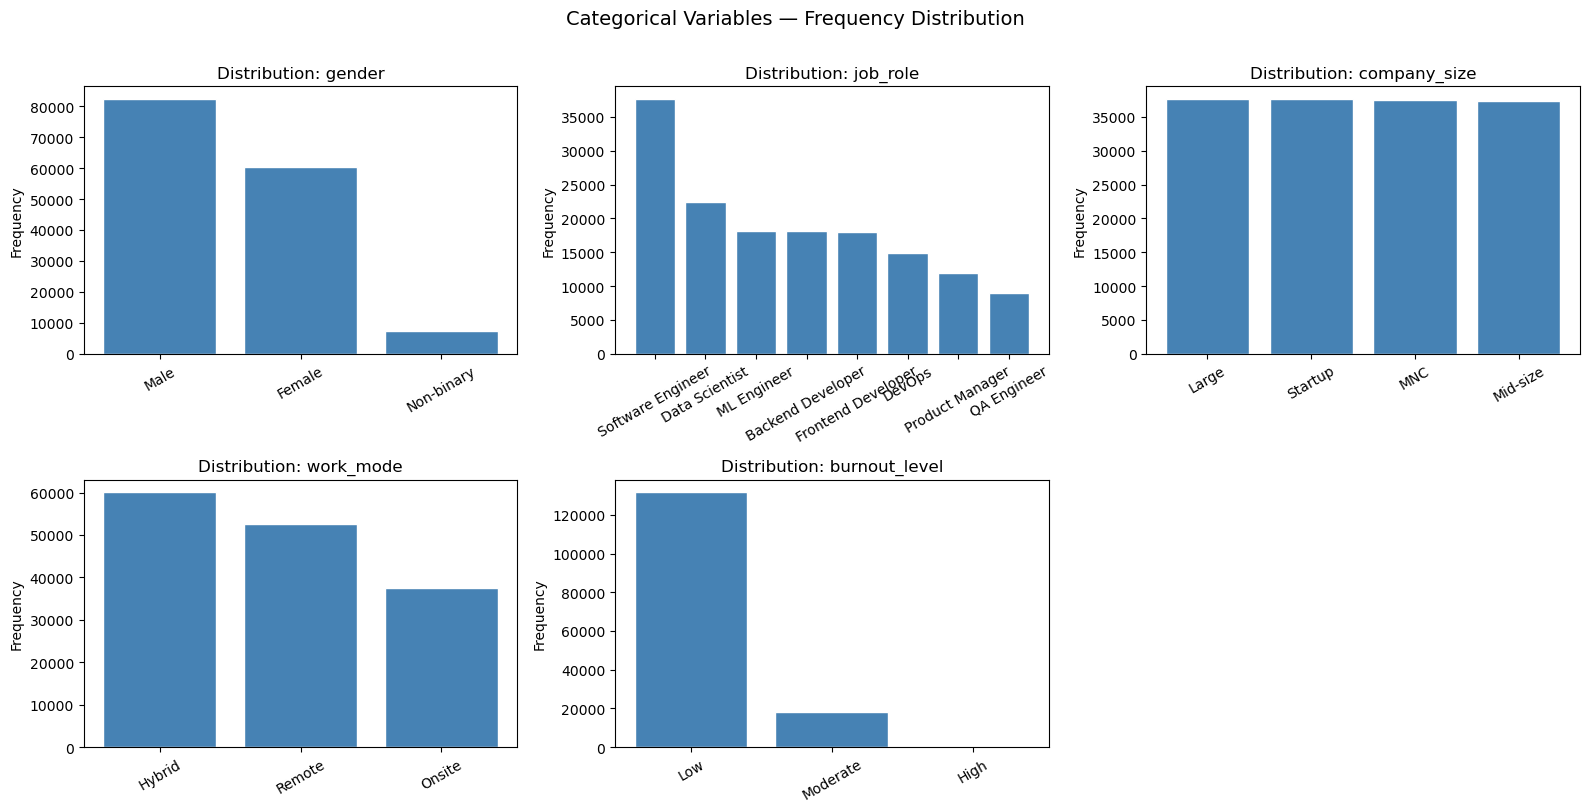

In [5]:
cat_cols = ['gender', 'job_role', 'company_size', 'work_mode', 'burnout_level']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].axis('off')
plt.suptitle('Categorical Variables — Frequency Distribution', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.5. Key Numerical Variables Distributions

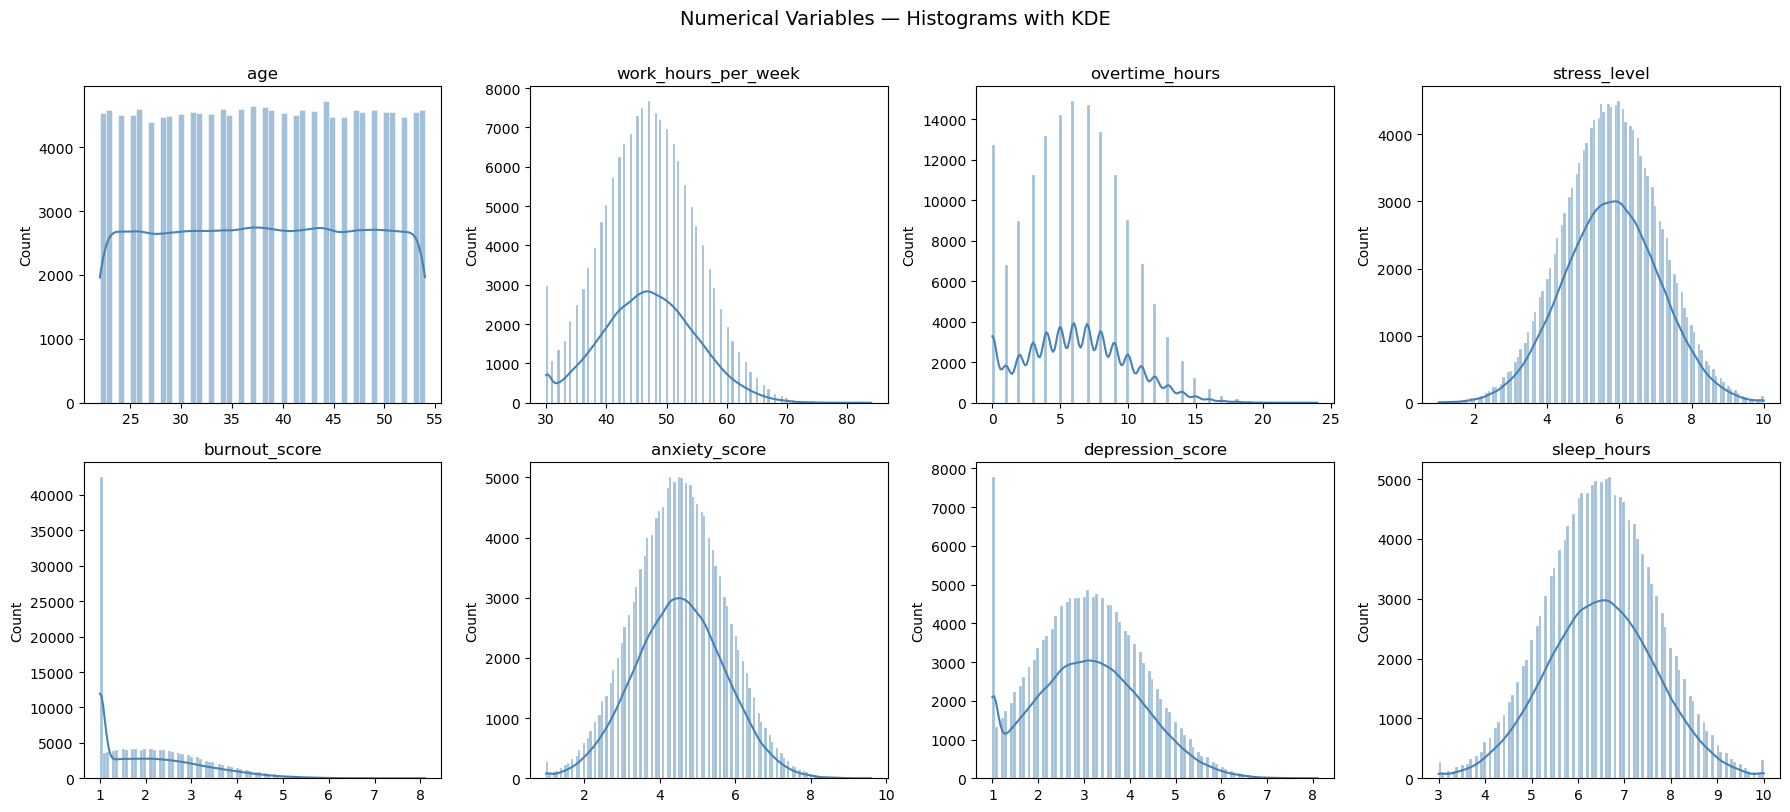

In [8]:
num_cols = ['age', 'work_hours_per_week', 'overtime_hours', 'stress_level',
            'burnout_score', 'anxiety_score', 'depression_score', 'sleep_hours']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Numerical Variables — Histograms with KDE', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1.6. Binary Variables Distribution

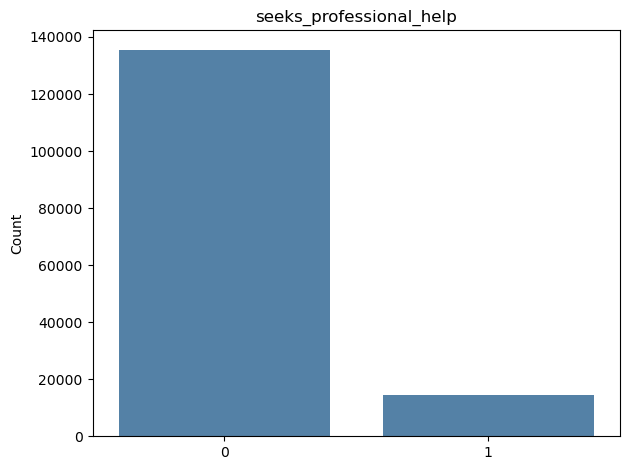

In [9]:
sns.countplot(x=df['seeks_professional_help'], color='steelblue')

plt.title('seeks_professional_help')
plt.xlabel('')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


## 1.7. Burnout Distribution by Categorical Variables

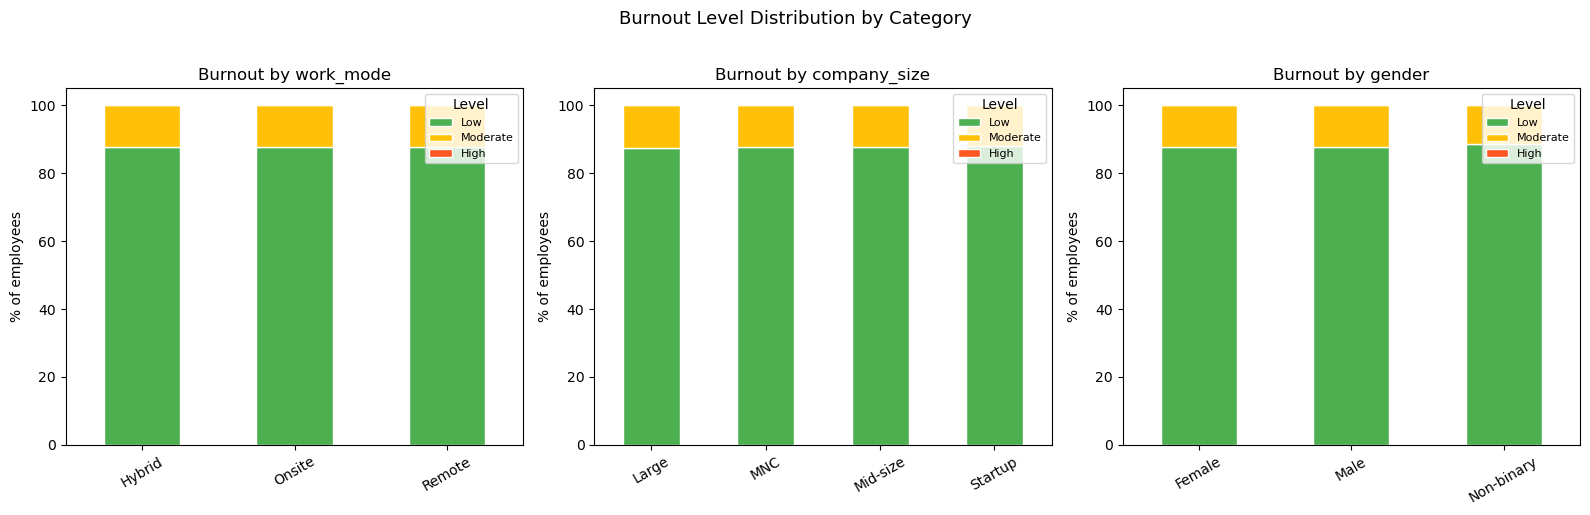

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['work_mode', 'company_size', 'gender']):
    orden_burnout = ['Low', 'Moderate', 'High', 'Critical']
    ct = pd.crosstab(df[col], df['burnout_level'])
    ct = ct.reindex(columns=[c for c in orden_burnout if c in ct.columns])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=ax,
                color=['#4CAF50', '#FFC107', '#FF5722', '#9C27B0'],
                edgecolor='white')
    ax.set_title(f'Burnout by {col}')
    ax.set_ylabel('% of employees')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Level', fontsize=8, loc='upper right')

plt.suptitle('Burnout Level Distribution by Category', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 1.8. Average Scores by Role

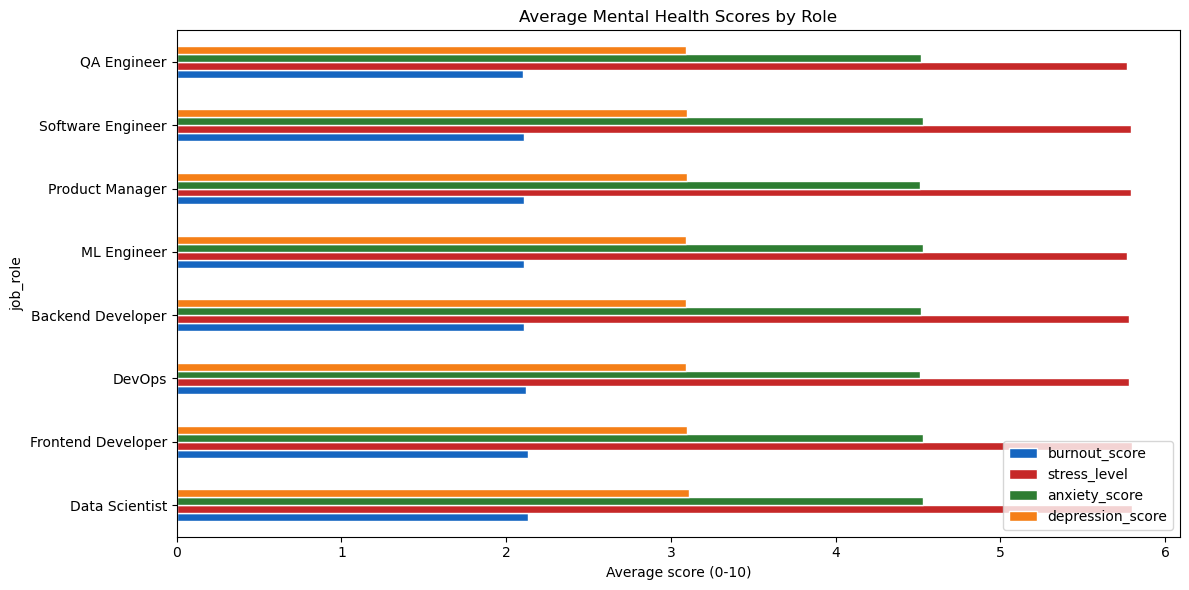

In [11]:
scores = ['burnout_score', 'stress_level', 'anxiety_score', 'depression_score']
avg_por_rol = df.groupby('job_role')[scores].mean().round(2).sort_values('burnout_score', ascending=False)

avg_por_rol.plot(kind='barh', figsize=(12, 6),
                 color=['#1565C0', '#C62828', '#2E7D32', '#F57F17'],
                 edgecolor='white')

plt.title('Average Mental Health Scores by Role')
plt.xlabel('Average score (0-10)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 1.9. Correlation Map

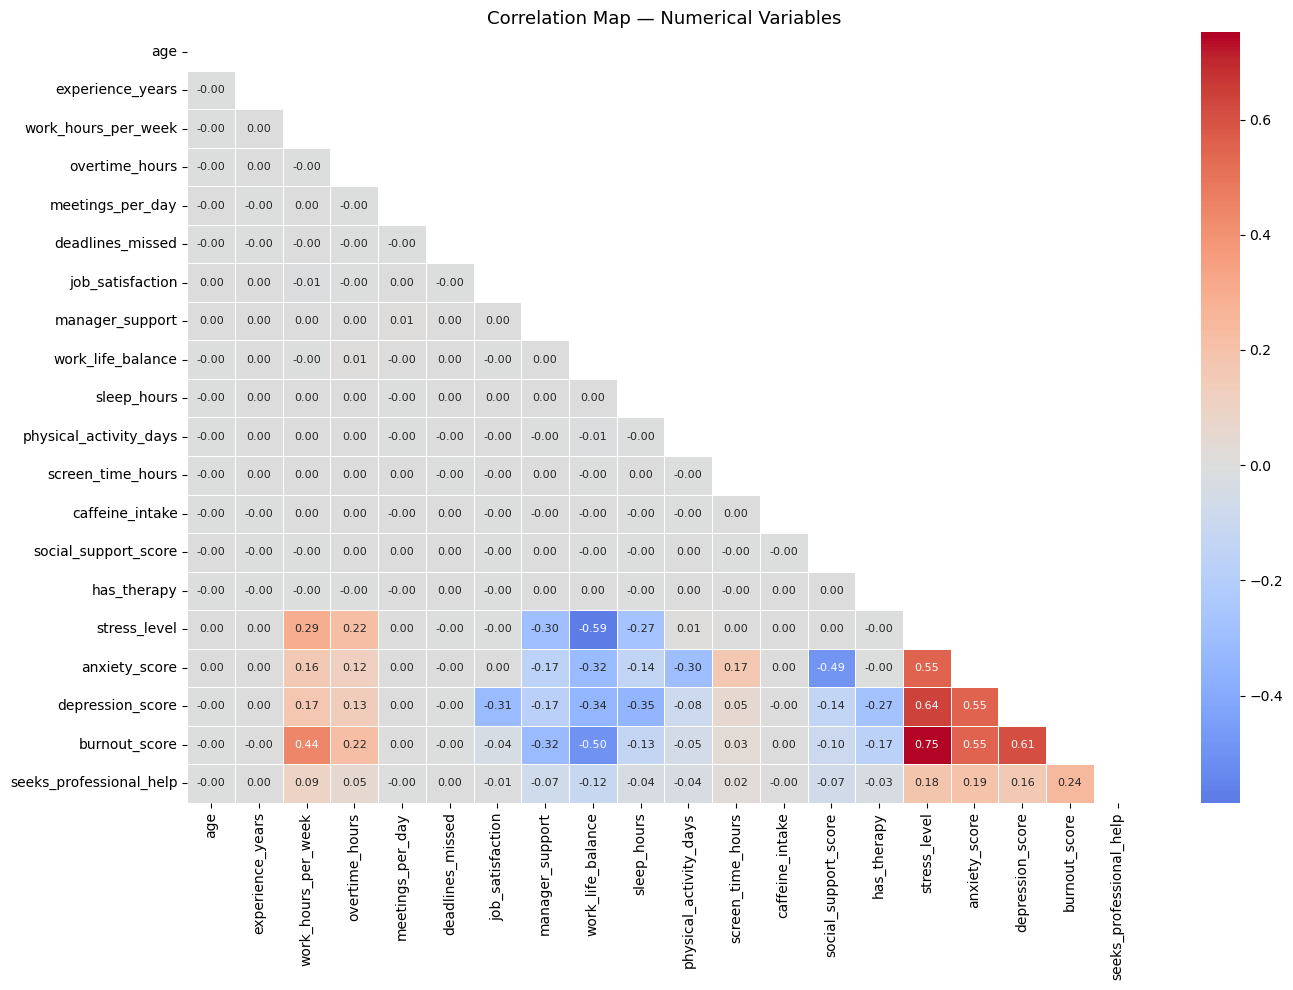

In [12]:
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Map — Numerical Variables', fontsize=13)
plt.tight_layout()
plt.show()

## 1.10. Work Hours vs. Burnout Score Relationship

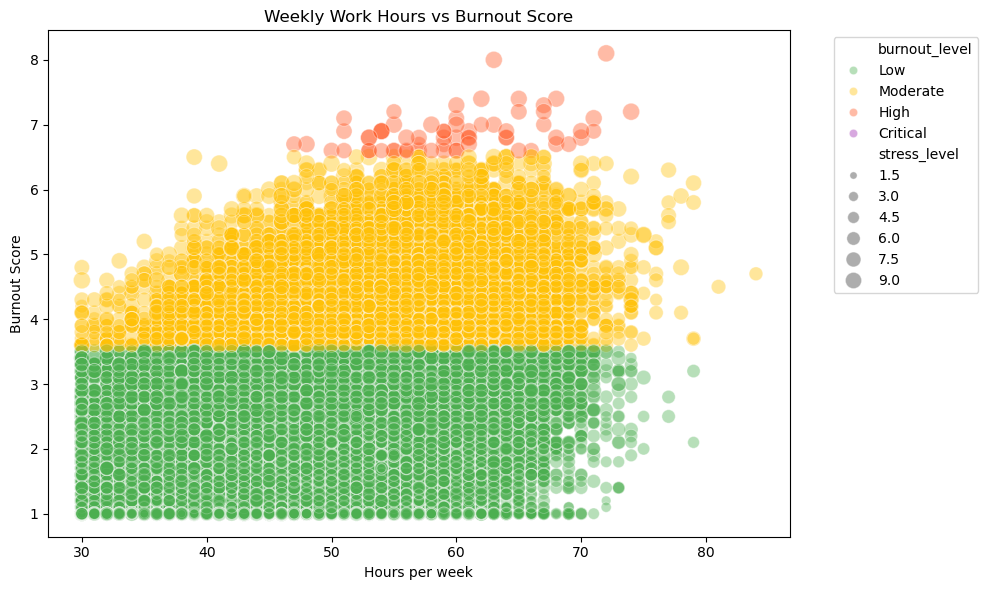

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='work_hours_per_week', y='burnout_score',
                hue='burnout_level', alpha=0.4, size='stress_level',
                sizes=(20, 150),
                hue_order=['Low', 'Moderate', 'High', 'Critical'],
                palette=['#4CAF50', '#FFC107', '#FF5722', '#9C27B0'])

plt.title('Weekly Work Hours vs Burnout Score')
plt.xlabel('Hours per week')
plt.ylabel('Burnout Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

# 1.11 Additional Calculations

In [14]:
# KPI 1
avg_burnout_score = df['burnout_score'].mean()

# KPI 2
pct_help_seeking = df['seeks_professional_help'].mean() * 100

# KPI 3
pct_high_burnout = (df['burnout_level'] == 'high').mean() * 100

# KPI 4
avg_burnout_women = df[df['gender'] == 'Female']['burnout_score'].mean()

# KPI 5
avg_burnout_men = df[df['gender'] == 'Male']['burnout_score'].mean()

# Percentage of men vs women

women = df[df['gender'] == 'Female']
men = df[df['gender'] == 'Male']

avg_women = df[df['gender'] == 'Female']['burnout_score'].mean()
avg_men = df[df['gender'] == 'Male']['burnout_score'].mean()

print(f"Women: {len(women)}")
print(f"Men: {len(men)}")

print(f"Average burnout: {avg_burnout_score:.2f}")
print(f"% seek help: {pct_help_seeking:.2f}%")
print(f"% high burnout: {pct_high_burnout:.5f}%")
print(f"Average burnout women: {avg_burnout_women:.2f}")
print(f"Average burnout men: {avg_burnout_men:.2f}")


Women: 60281
Men: 82286
Average burnout: 2.11
% seek help: 9.63%
% high burnout: 0.00000%
Average burnout women: 2.11
Average burnout men: 2.11


# 2. Feature Engineering (new columns for the dashboard)

## 2.1. Categorize age into ranges to see who suffers most from burnout.

In [15]:
bins_edad = [18, 25, 35, 45, 60]
labels_edad = ['Gen Z (18-25)', 'Millennials (26-35)', 'Gen X (36-45)', 'Senior (46+)']
df['age_group'] = pd.cut(df['age'], bins=bins_edad, labels=labels_edad)
df['age_group'].value_counts()

age_group
Gen X (36-45)          45836
Millennials (26-35)    45163
Senior (46+)           40885
Gen Z (18-25)          18116
Name: count, dtype: int64

# 3. Dashboard

In [16]:
import dash
from dash import dcc, html, Input, Output
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from wordcloud import WordCloud
import base64
from io import BytesIO
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ─────────────────────────────────────────
# GLOBAL PALETTE AND STYLES
# ─────────────────────────────────────────
BG        = "#F4F6FB"
CARD_BG   = "#FFFFFF"
ACCENT1   = "#1A2744"
ACCENT2   = "#ED6A5A"
ACCENT3   = "#9BC1BC"
ACCENT4   = "#5B6EB5"
FONT      = "Segoe UI, sans-serif"

KPI_COLORS = {                       # Colors for general KPIs
    "burnout":  "#E8401C",
    "help":     "#2AA876",
    "risk":     "#F0A500",
    "gender_f": "#9B59B6",
    "gender_m": "#3498DB",
}

ORDER_BURNOUT = ["Low", "Moderate", "High"]   # Colors for burnout levels
CMAP_BURNOUT = {
    "Low":      "#9BC1BC",
    "Moderate": "#ED6A5A",
    "High":     "#8B0000",
}

EXCLUIR = ["seeks_professional_help"]

# ─────────────────────────────────────────
# BURNOUT LEVEL BY SCORE
# ─────────────────────────────────────────
def burnout_level_label(score):
    if score < 3.5:
        return "Low", "#9BC1BC"
    elif score < 6.5:
        return "Moderate", "#ED6A5A"
    else:
        return "High", "#8B0000"

# ─────────────────────────────────────────
# TOP 10 IMPORTANCE ( Calculated with Random Forest in different notebook)
# ─────────────────────────────────────────
IMP_BURNOUT = pd.DataFrame([
    {"variable": "work_life_balance",       "importance": 0.2189},
    {"variable": "work_hours_per_week",     "importance": 0.1856},
    {"variable": "manager_support",         "importance": 0.1391},
    {"variable": "overtime_hours",          "importance": 0.0531},
    {"variable": "social_support_score",    "importance": 0.0470},
    {"variable": "sleep_hours",             "importance": 0.0443},
    {"variable": "job_satisfaction",        "importance": 0.0359},
    {"variable": "experience_years",        "importance": 0.0317},
    {"variable": "screen_time_hours",       "importance": 0.0315},
    {"variable": "seeks_professional_help", "importance": 0.0531},
]).sort_values("importance", ascending=True)

IMP_HELP = pd.DataFrame([
    {"variable": "burnout_score",        "importance": 0.1260},
    {"variable": "anxiety_score",        "importance": 0.1020},
    {"variable": "stress_level",         "importance": 0.0775},
    {"variable": "depression_score",     "importance": 0.0620},
    {"variable": "work_life_balance",    "importance": 0.0525},
    {"variable": "manager_support",      "importance": 0.0500},
    {"variable": "social_support_score", "importance": 0.0495},
    {"variable": "burnout_level",        "importance": 0.0475},
    {"variable": "experience_years",     "importance": 0.0470},
    {"variable": "screen_time_hours",    "importance": 0.0460},
]).sort_values("importance", ascending=True)

VAR_LABELS = {
    "work_life_balance":       "Work-Life Balance",
    "work_hours_per_week":     "Work Hours / Week",
    "manager_support":         "Manager Support",
    "overtime_hours":          "Overtime Hours",
    "social_support_score":    "Social Support Score",
    "sleep_hours":             "Sleep Hours",
    "job_satisfaction":        "Job Satisfaction",
    "experience_years":        "Experience Years",
    "screen_time_hours":       "Screen Time Hours",
    "seeks_professional_help": "Seeks Professional Help",
    "burnout_score":           "Burnout Score",
    "anxiety_score":           "Anxiety Score",
    "stress_level":            "Stress Level",
    "depression_score":        "Depression Score",
    "burnout_level":           "Burnout Level",
    "age":                     "Age",
}

def readable(v):
    return VAR_LABELS.get(v, v.replace("_", " ").title())

# ─────────────────────────────────────────
# GRADIENTE for RF bars based on #ED6A5A
# ─────────────────────────────────────────
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

def interpolate_color(color1_hex, color2_hex, t):
    r1, g1, b1 = hex_to_rgb(color1_hex)
    r2, g2, b2 = hex_to_rgb(color2_hex)
    r = int(r1 + (r2 - r1) * t)
    g = int(g1 + (g2 - g1) * t)
    b = int(b1 + (b2 - b1) * t)
    return f"#{r:02x}{g:02x}{b:02x}"

def build_importance_fig(imp_df, target):
    imp_sorted = imp_df.sort_values("importance", ascending=False).copy()
    imp_sorted["label"] = imp_sorted["variable"].map(readable)

    title = ("Top 10 - Important Variables - Burnout Level"
             if target == "burnout_level"
             else "Top 10 - Important Variables - Seeks Professional Help")

    COLOR_LOW  = "#FADADD"
    COLOR_HIGH = "#ED6A5A"

    imp_vals = imp_sorted["importance"].values
    imp_min, imp_max = imp_vals.min(), imp_vals.max()
    ts = [(v - imp_min) / (imp_max - imp_min) if imp_max != imp_min else 1.0
          for v in imp_vals]
    colors = [interpolate_color(COLOR_LOW, COLOR_HIGH, t) for t in ts]
    imp_sorted["color"] = colors

    imp_sorted = imp_sorted.sort_values("importance", ascending=True)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=imp_sorted["importance"],
        y=imp_sorted["label"],
        orientation="h",
        marker_color=imp_sorted["color"],
        text=[f"{v*100:.1f}%" for v in imp_sorted["importance"]],
        textposition="outside",
        cliponaxis=False,
    ))
    fig.update_layout(
        title=dict(
            text=title,
            font=dict(size=12, color=ACCENT1),
            x=0.5,
            xanchor="center",
        ),
        xaxis=dict(
            showticklabels=False,
            showgrid=False,
            zeroline=False,
            title=None,
        ),
        yaxis=dict(
            automargin=True,
            tickfont=dict(size=13),
        ),
        paper_bgcolor=CARD_BG,
        plot_bgcolor=CARD_BG,
        margin=dict(l=10, r=80, t=45, b=10),
        height=380,
        showlegend=False,
        bargap=0.5,
    )
    return fig


# ─────────────────────────────────────────
# PROFILE WORDCLOUD — STATIC (based on 3 variables = job_role, work_mode, company_size)
# ─────────────────────────────────────────
_wc_cache = None

def make_profile_wordcloud_static(df_full):
    global _wc_cache
    if _wc_cache is not None:
        return _wc_cache

    df2 = df_full.copy()
    df2["mode_abbr"] = df2["work_mode"].str[0]
    size_map = {"Small": "S", "Medium": "M", "Large": "L", "MNC": "MNC"}
    df2["size_abbr"] = df2["company_size"].map(size_map).fillna(df2["company_size"].str[0])
    df2["perfil"] = (
        df2["job_role"].str.replace(" ", "") + "_" +
        df2["mode_abbr"] + "_" +
        df2["size_abbr"]
    )
    df_grouped = df2.groupby("perfil")["burnout_score"].mean()
    freq = df_grouped.to_dict()
    wc = WordCloud(
        width=1100, height=580, background_color="white",
        colormap="RdYlGn_r", max_font_size=90, min_font_size=10,
        prefer_horizontal=0.80, margin=6,
    ).generate_from_frequencies(freq)
    buf = BytesIO()
    fig_wc, ax = plt.subplots(figsize=(11, 4), dpi=90)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    legend_text = (
        "Work Mode:\n"
        "R = Remote\nH = Hybrid\nO = On-site\n\n"
        "Company Size:\nS   = Small\nM   = Medium\nL   = Large\nMNC = MNC"
    )
    ax.text(1.01, 0.5, legend_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='center',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#F8FAFF",
                      edgecolor="#CCCCCC", alpha=0.9),
            fontfamily="monospace")
    fig_wc.patch.set_facecolor("white")
    plt.tight_layout(pad=0.3)
    fig_wc.savefig(buf, format="png", bbox_inches="tight", facecolor="white", dpi=90)
    plt.close(fig_wc)
    buf.seek(0)
    result = "data:image/png;base64," + base64.b64encode(buf.read()).decode()
    _wc_cache = result
    return result


# ─────────────────────────────────────────
# BUBBLE SCATTER
# ─────────────────────────────────────────
def make_bubble_scatter(dff, xvar, yvar="burnout_score", xlabel=None):
    if xvar not in dff.columns:
        return go.Figure()
    tmp = dff[[xvar, yvar, "burnout_level"]].dropna().copy()
    tmp["xr"] = tmp[xvar].round(1)
    tmp["yr"] = tmp[yvar].round(1)
    grp = tmp.groupby(["xr", "yr", "burnout_level"]).size().reset_index(name="count")

    x_display = xlabel if xlabel else readable(xvar)
    y_display = readable(yvar)

    fig = go.Figure()
    for lvl in ORDER_BURNOUT:
        sub = grp[grp["burnout_level"] == lvl]
        fig.add_trace(go.Scatter(
            x=sub["xr"] if not sub.empty else [],
            y=sub["yr"] if not sub.empty else [],
            mode="markers",
            name=lvl,
            visible=True,
            marker=dict(
                size=sub["count"].clip(upper=80) if not sub.empty else [],
                sizemode="area",
                sizeref=2.0 * grp["count"].max() / (30 ** 2) if not grp.empty else 1,
                sizemin=4,
                color=CMAP_BURNOUT.get(lvl, "#CCCCCC"),
                opacity=0.75,
                line=dict(width=0.5, color="#FFFFFF"),
            ),
            hovertemplate=(
                f"<b>{x_display}</b>: %{{x}}<br><b>{y_display}</b>: %{{y}}<br>"
                "<b>Level</b>: %{fullData.name}<br><b>People</b>: %{marker.size}<extra></extra>"
            )
        ))

    if len(tmp) > 2:
        z = np.polyfit(tmp[xvar], tmp[yvar], 1)
        p = np.poly1d(z)
        xr = np.linspace(tmp[xvar].min(), tmp[xvar].max(), 60)
        fig.add_trace(go.Scatter(
            x=xr, y=p(xr), mode="lines",
            line=dict(color=ACCENT1, width=1.5, dash="dash"),
            name="Trend",
            showlegend=True,
        ))

    fig.update_layout(
        paper_bgcolor=CARD_BG,
        plot_bgcolor=CARD_BG,
        margin=dict(l=60, r=20, t=20, b=60),
        showlegend=True,
        legend=dict(orientation="h", y=1.08, font=dict(size=10), title_text=""),
        # ── CHANGE: axes with visible line and titles ──
        xaxis=dict(
            title=x_display,
            title_font=dict(size=11, color=ACCENT1),
            showgrid=True,
            gridcolor="#F0F0F0",
            zeroline=False,
            showline=True,
            linecolor="#CCCCCC",
            linewidth=1.5,
            mirror=False,
        ),
        yaxis=dict(
            title=y_display,
            title_font=dict(size=11, color="#9BC1BC"),
            tickfont=dict(color="#9BC1BC"),
            showgrid=True,
            gridcolor="#F0F0F0",
            zeroline=False,
            showline=True,
            linecolor="#CCCCCC",
            linewidth=1.5,
            mirror=False,
        ),
    )
    return fig


# ─────────────────────────────────────────
# STYLES
# ─────────────────────────────────────────
CARD_STYLE = {
    "backgroundColor": CARD_BG, "borderRadius": "10px",
    "padding": "14px 16px", "boxShadow": "0 2px 12px rgba(0,0,0,0.07)",
    "boxSizing": "border-box",
}
SECTION_TITLE = {
    "color": ACCENT1, "margin": "0 0 8px 0", "fontSize": "10px",
    "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.7px",
}

def kpi_card_profile(title, value_general, value_profile, color, unit="", is_pct=False):     # KPIs for filtered profiles 
    try:
        diff = float(value_profile) - float(value_general)
        arrow = "▲" if diff > 0 else "▼" if diff < 0 else "●"
        diff_color = "#e74c3c" if diff > 0 else "#27ae60" if diff < 0 else "#888"
        suffix = " pp" if is_pct else ""
        diff_text = f"{arrow} {abs(diff):.1f}{suffix} vs general"
    except Exception:
        diff_text = ""
        diff_color = "#888"
    return html.Div([
        html.P(title, style={"margin": "0 0 1px 0", "fontSize": "8.5px", "color": "#888",
                             "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.3px"}),
        html.H3(f"{float(value_profile):.1f}{unit}", style={"margin": "0", "color": color,
                                                              "fontSize": "17px", "fontWeight": "800"}),
        html.P(diff_text, style={"margin": "1px 0 0 0", "fontSize": "9px",
                                  "color": diff_color, "fontWeight": "600"}),
    ], style={"backgroundColor": "#f8faff", "borderRadius": "7px", "padding": "7px 10px",
               "borderLeft": f"3px solid {color}", "marginBottom": "5px", "boxSizing": "border-box"})


# ─────────────────────────────────────────
# GLOSSARY
# ─────────────────────────────────────────
GLOSARIO_ITEMS = [
    ("Burnout Score", "Score from 0 to 10 that measures the overall level of work exhaustion."),
    ("Burnout Level", "Exhaustion category: Low → Moderate → High."),
    ("Stress Level", "Subjective perception of work pressure (0-10)."),
    ("Anxiety Score", "Measure of anxiety symptoms in the work context (0-10)."),
    ("Depression Score", "Indicator of depressive symptoms related to the work environment (0-10)."),
    ("Work-Life Balance", "Perceived balance between personal and professional life (0-10)."),
    ("Manager Support", "Perceived support from direct supervisor (0-10)."),
    ("Social Support Score", "Social support network available to the employee (0-10)."),
    ("Job Satisfaction", "General satisfaction with work (0-10)."),
    ("Sleep Hours", "Average hours of sleep per night."),
    ("Screen Time Hours", "Daily hours in front of screens."),
    ("Work Hours / Week", "Total hours worked per week."),
    ("Overtime Hours", "Extra hours worked beyond regular schedule."),
    ("Experience Years", "Number of years the employee has been working."),
    ("Age", "Age of employees in years."),
    ("Seeks Professional Help", "Whether the employee seeks psychological help (Yes / No)."),
    ("Work Mode", "Work modality: On-site, Remote or Hybrid."),
    ("Company Size", "Organization size: Small, Medium, Large or MNC."),
    ("Job Role", "The position or role of the employee within the organization."),
    ("Gender", "Gender declared by the employee."),
    ("Age Group", "Generational brackets: Gen Z (18-25), Millennials (26-35), Gen X (36-45), Senior (46+)."),
    ("Random Forest (RF)", "ML model that trains hundreds of decision trees. Importance = how much each variable contributes."),
]

def glosario_panel():
    rows = []
    for term, defn in GLOSARIO_ITEMS:
        rows.append(html.Div([
            html.Span(term, style={"fontWeight": "700", "color": ACCENT1, "fontSize": "11px",
                                   "display": "block", "marginBottom": "1px"}),
            html.Span(defn, style={"color": "#666", "fontSize": "10.5px", "lineHeight": "1.4"}),
        ], style={"borderBottom": "1px solid #F0F0F0", "paddingBottom": "6px", "marginBottom": "6px"}))
    return html.Div([
        html.P("📖 Glossary of Terms", style={**SECTION_TITLE, "fontSize": "12px", "marginBottom": "10px"}),
        *rows,
    ], style={**CARD_STYLE, "flex": "0 0 250px", "overflowY": "auto", "maxHeight": "620px", "fontSize": "10px"})


# ─────────────────────────────────────────
# EXPLANATIONS
# ─────────────────────────────────────────
BURNOUT_EXPLANATION = html.Div([
    html.P("🔥 What is Burnout?", style={
        "fontWeight": "800", "color": ACCENT1, "fontSize": "13px",
        "margin": "0 0 6px 0", "letterSpacing": "0.3px",
    }),
    html.P(
        "According to WHO, burnout (occupational burnout) is: a syndrome conceptualized as a result of chronic workplace stress that has not been successfully managed.",
        style={"fontSize": "12.5px", "color": "#555", "margin": 0, "lineHeight": "1.5"},
    ),
], style={
    "backgroundColor": "#FFF8F0", "border": "1px solid #FDDCB5",
    "borderRadius": "8px", "padding": "12px 14px", "marginBottom": "10px",
})

RF_EXPLANATION = html.Div([
    html.P("🌲 What is Random Forest?", style={
        "fontWeight": "800", "color": ACCENT1, "fontSize": "13px", "margin": "0 0 5px 0",
    }),
    html.P(
        "A Random Forest is an artificial intelligence model that analyzes several factors and combines many decisions to predict an outcome." 
         "'Importance' measures how much it reduces error when using that variable." 
         "High percentage = very predictive variable for burnout.",
        style={"fontSize": "12.5px", "color": "#555", "margin": 0, "lineHeight": "1.5"},
    ),
], style={
    "backgroundColor": "#F0F8FF", "border": "1px solid #B3D4F0",
    "borderRadius": "8px", "padding": "10px 14px", "marginTop": "10px",
})


# ─────────────────────────────────────────
# APP
# ─────────────────────────────────────────
app = dash.Dash(__name__, suppress_callback_exceptions=True)
app.title = "Burnout & Mental Health — Dashboard"

app.layout = html.Div(
    id="main-container",
    style={"backgroundColor": BG, "fontFamily": FONT, "padding": "14px 20px",
           "maxWidth": "100%", "boxSizing": "border-box"},
    children=[
        # ── HEADER ────────────────────────────────
        html.Div([
            html.H1(" FACTORS THAT IMPACT WORKPLACE BURNOUT", style={
                "color": ACCENT1, "margin": "0", "fontSize": "25px",
                "fontWeight": "800", "letterSpacing": "0.2px", "textAlign": "center",
            }),
            html.P("Dataset: Employee Mental Health & Burnout · Kaggle", style={
                "color": "#8899aa", "margin": "2px 0 0 0", "fontSize": "10px", "textAlign": "center",
            }),
        ], style={"marginBottom": "12px", "borderBottom": f"3px solid {ACCENT1}", "paddingBottom": "10px"}),

        # ── ROW 0 — General KPIs ──────────────────────────
        html.Div([
            html.Div([
                html.Span("📊", style={"fontSize": "16px", "marginRight": "6px"}),
                html.Span("General Statistics", style={
                    "fontSize": "12px", "fontWeight": "800", "color": ACCENT1,
                    "textTransform": "uppercase", "letterSpacing": "0.8px",
                }),
            ], style={"display": "flex", "alignItems": "center", "marginBottom": "12px",
                      "paddingBottom": "8px", "borderBottom": f"2px solid {BG}"}),
            html.Div(id="kpi-row-static", style={"display": "flex", "gap": "10px", "alignItems": "stretch"}),
        ], style={**CARD_STYLE, "marginBottom": "12px"}),

        # ── ROW 1 — RF + Glossary ──
        html.Div([
            html.Div([
                BURNOUT_EXPLANATION,
                html.Div([
                    html.P("📈 Variable Importance (Random Forest)", style={**SECTION_TITLE, "margin": "0"}),
                    dcc.RadioItems(
                        id="imp-target",
                        options=[
                            {"label": " Predicts Burnout Level",           "value": "burnout_level"},
                            {"label": " Predicts Seeks Professional Help", "value": "seeks_professional_help"},
                        ],
                        value="burnout_level", inline=True,
                        style={"fontSize": "11px", "color": "#555"},
                        labelStyle={"marginRight": "14px"},
                    ),
                ], style={"display": "flex", "justifyContent": "space-between",
                          "alignItems": "center", "marginBottom": "6px",
                          "flexWrap": "wrap", "gap": "6px"}),
                dcc.Graph(id="imp-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "360px"}),     # Chart height
                RF_EXPLANATION,
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0", "display": "flex", "flexDirection": "column"}),
            glosario_panel(),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px", "alignItems": "stretch"}),

        # ── ROW 2 — Filters + KPIs | WordCloud (STATIC) ──
        html.Div([
            html.Div([
                # Sticky banner
                html.Div([
                    html.Span("🎯 ", style={"fontSize": "12px"}),
                    html.Span("Profile: ", style={"fontWeight": "700", "color": "#fff",
                                                  "fontSize": "10px", "marginRight": "4px"}),
                    html.Span(id="profile-label-sticky",
                              style={"color": "#ffe0d0", "fontSize": "10px", "fontWeight": "600"}),
                ], style={
                    "position": "fixed", "top": "0", "left": "0", "right": "0", "zIndex": "9999",
                    "backgroundColor": ACCENT1, "padding": "6px 20px",
                    "boxShadow": "0 2px 8px rgba(0,0,0,0.18)",
                    "display": "flex", "alignItems": "center", "gap": "4px",
                }),

                html.P("⚙️ Filters", style=SECTION_TITLE),
                dcc.Dropdown(id="f-role",    options=[], multi=True,
                             placeholder="💼 Role",          style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-mode",      options=[], multi=True,
                             placeholder="🏠 Work Mode", style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-size",      options=[], multi=True,
                             placeholder="🏢 Company Size",             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-gender",      options=[], multi=True,
                             placeholder="👤 Gender",  style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Dropdown(id="f-age-group", options=[], multi=True,
                             placeholder="🎂 Age Group",   style={"marginBottom": "10px", "fontSize": "12px"}),
                html.Hr(style={"borderColor": "#e0e4ef", "margin": "6px 0"}),
                html.P("📊 Profile vs General", style=SECTION_TITLE),
                html.Div(id="kpi-profile", style={
                    "flex": "1", "display": "flex", "flexDirection": "column", "justifyContent": "flex-start",
                }),
            ], style={**CARD_STYLE, "flex": "0 0 200px", "display": "flex", "flexDirection": "column"}),

            # WordCloud STATIC — no filters
            html.Div([
                html.P(
                    "Most critical profiles by Burnout (Role_Mode_Size)",
                    style={**SECTION_TITLE, "textAlign": "center", "margin": "0 0 6px 0"}
                ),
                html.P(
                    "Word size = average burnout of the profile",
                    style={"fontSize": "11px", "color": "#999", "margin": "0 0 10px 0", "textAlign": "center"}
                ),
                html.Img(
                    id="wc-profile-img",
                    style={
                        "width": "100%",
                        "borderRadius": "8px",
                        "maxHeight": "520px",
                        "minHeight": "380px",
                        "objectFit": "contain",
                    }
                ),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0",
                      "display": "flex", "flexDirection": "column", "alignItems": "stretch"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px", "alignItems": "stretch"}),

        # ── ROW 3 — Pie Chart | Correlation ──
        html.Div([
            html.Div([
                html.P("🥧 Pie Chart — Burnout Level", style=SECTION_TITLE),
                dcc.Graph(id="dist-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "360px"}),
            ], style={**CARD_STYLE, "flex": "0 0 340px", "minWidth": "0",
                      "display": "flex", "flexDirection": "column"}),

            html.Div([
                html.P("📉 Impact on Burnout Score", style=SECTION_TITLE),
                html.Div([
                    html.Label("Filter |R| >=", style={
                        "fontSize": "12px", "color": "#666", "whiteSpace": "nowrap",
                        "fontWeight": "600",
                    }),
                    html.Div(
                        dcc.Slider(
                            id="corr-slider", min=0, max=0.9, step=0.05, value=0.3,
                            marks={i/10: str(round(i/10, 1)) for i in range(0, 10)},
                            tooltip={"placement": "bottom"},
                        ),
                        style={"flex": "1", "maxWidth": "280px"},
                    ),
                    html.Div([
                        html.Span(" Increases Burnout", style={
                            "fontSize": "10px", "color": "#D0A9FE", "fontWeight": "700",
                            "marginRight": "10px",
                        }),
                        html.Span(" Reduces Burnout", style={
                            "fontSize": "10px", "color": ACCENT3, "fontWeight": "700",
                        }),
                    ], style={"whiteSpace": "nowrap"}),
                ], style={
                    "display": "flex", "alignItems": "center", "gap": "10px",
                    "marginBottom": "6px", "flexWrap": "wrap",
                }),
                dcc.Graph(id="impact-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "320px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px"}),

        # ── ROW 4 — Scatter potentiators | protectors ──
        html.Div([
            html.Div([
                html.P("🔴 Burnout Potentiators", style={**SECTION_TITLE, "color": ACCENT2}),
                html.P("Bubble = density of people at that point",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Dropdown(id="var-pos", placeholder="Potentiator variable",
                             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Graph(id="scatter-pos", config={"displayModeBar": False},
                          style={"width": "100%", "height": "300px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),

            html.Div([
                html.P("🟢 Burnout Protectors", style={**SECTION_TITLE, "color": ACCENT3}),
                html.P("Bubble = density of people at that point",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Dropdown(id="var-neg", placeholder="Protector variable",
                             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Graph(id="scatter-neg", config={"displayModeBar": False},
                          style={"width": "100%", "height": "300px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px"}),

        # ── ROW 5 — Scatter Numeric | Boxplot ──
        html.Div([
            html.Div([
                html.Div([
                    html.P("📊 Burnout Score vs Numeric Variable", style={**SECTION_TITLE, "margin": "0"}),
                    dcc.Dropdown(
                        id="var-scatter-num",
                        # ── CHANGE: English labels ──        # The use of English variables is respected
                        options=[
                            {"label": "⏰ Work Hours / Week",    "value": "work_hours_per_week"},
                            {"label": "🎂 Age",                  "value": "age"},
                            {"label": "📅 Experience Years",     "value": "experience_years"},
                        ],
                        value="work_hours_per_week", clearable=False,
                        style={"width": "240px", "fontSize": "12px"},
                    ),
                ], style={"display": "flex", "justifyContent": "space-between",
                          "alignItems": "center", "marginBottom": "8px",
                          "flexWrap": "wrap", "gap": "6px"}),
                html.P("Bubble = density · Color = burnout level",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Graph(id="scatter-num", config={"displayModeBar": False},
                          style={"width": "100%", "height": "360px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0"}),

            html.Div([
                html.P("📦 Boxplot by Burnout Level", style=SECTION_TITLE),
                html.P("Variables ordered by correlation with burnout score",
                       style={"fontSize": "9px", "color": "#999", "margin": "-5px 0 6px 0"}),
                dcc.Dropdown(id="boxplot-var", placeholder="Variable to analyze",
                             style={"marginBottom": "6px", "fontSize": "12px"}),
                dcc.Graph(id="boxplot-graph", config={"displayModeBar": False},
                          style={"width": "100%", "height": "320px"}),
            ], style={**CARD_STYLE, "flex": "1", "minWidth": "0",
                      "display": "flex", "flexDirection": "column"}),
        ], style={"display": "flex", "gap": "10px", "marginBottom": "12px"}),

        # ── FOOTER ──────────────────────────────────────────
        html.Div([
            html.P([
                "📊 Data source: ",
                html.A("Employee Mental Health & Burnout Dataset — Kaggle",
                       href="https://www.kaggle.com/datasets/waqi786/remote-work-and-mental-health",
                       target="_blank", style={"color": ACCENT4, "fontWeight": "600"}),
                " · Exploratory analysis with Random Forest · Dashboard v8"
            ], style={"fontSize": "10px", "color": "#999", "margin": 0, "textAlign": "center"}),
        ], style={"borderTop": "1px solid #DDE3EF", "paddingTop": "10px", "marginTop": "4px"}),
    ]
)


# ─────────────────────────────────────────
# CALLBACKS
# ─────────────────────────────────────────
@app.callback(
    Output("f-gender",       "options"),
    Output("f-mode",         "options"),
    Output("f-role",         "options"),
    Output("f-size",         "options"),
    Output("f-age-group",    "options"),
    Output("kpi-row-static", "children"),
    Output("wc-profile-img", "src"),
    Input("main-container",  "id"),
)
def init(_):
    g_opts  = [{"label": i, "value": i} for i in sorted(df["gender"].dropna().unique())]
    m_opts  = [{"label": i, "value": i} for i in sorted(df["work_mode"].dropna().unique())]
    r_opts  = [{"label": i, "value": i} for i in sorted(df["job_role"].dropna().unique())]
    s_opts  = [{"label": i, "value": i} for i in sorted(df["company_size"].dropna().unique())]
    ag_opts = [{"label": i, "value": i} for i in sorted(df["age_group"].dropna().unique())]

    burnout_mean = df["burnout_score"].mean()
    help_pct     = df["seeks_professional_help"].mean() * 100
    at_risk      = df["burnout_level"].isin(["Moderate", "High"]).mean() * 100
    n_high       = int(df["burnout_level"].isin(["High"]).sum())
    dff_f        = df[df["gender"] == "Female"]
    dff_m        = df[df["gender"] == "Male"]
    at_risk_f    = dff_f["burnout_level"].isin(["Moderate", "High"]).mean() * 100 if len(dff_f) > 0 else 0
    at_risk_m    = dff_m["burnout_level"].isin(["Moderate", "High"]).mean() * 100 if len(dff_m) > 0 else 0
    diff_gm      = at_risk_f - at_risk_m
    arrow        = "▲" if diff_gm > 0 else "▼" if diff_gm < 0 else "●"
    b_label, b_color = burnout_level_label(burnout_mean)

    mini_kpi_style = {
        "flex": "1", "textAlign": "center", "padding": "10px 8px",
        "borderRadius": "8px", "backgroundColor": BG,
        "minWidth": "0", "boxSizing": "border-box",
    }
    kpis = [
        html.Div([
            html.Div("🔥", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("Average Burnout", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                              "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{burnout_mean:.1f}", style={"margin": "0 0 2px 0", "color": KPI_COLORS["burnout"],
                                                   "fontSize": "22px", "fontWeight": "800", "lineHeight": "1"}),
            html.Span(f"Level: {b_label}", style={"fontSize": "10px", "fontWeight": "700", "color": b_color,
                                                   "backgroundColor": f"{b_color}18", "padding": "2px 8px",
                                                   "borderRadius": "20px", "border": f"1px solid {b_color}44",
                                                   "display": "inline-block", "marginTop": "2px"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['burnout']}"}),

        html.Div([
            html.Div("🤝", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("Seek Prof. Help", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{help_pct:.1f}%", style={"margin": 0, "color": KPI_COLORS["help"],
                                                "fontSize": "22px", "fontWeight": "800"}),
            html.P("of total employees", style={"margin": "3px 0 0 0", "fontSize": "9px", "color": "#aaa"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['help']}"}),

        html.Div([
            html.Div("⚠️", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("At Risk (>= Mod.)", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                  "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{at_risk:.1f}%", style={"margin": 0, "color": KPI_COLORS["risk"],
                                               "fontSize": "22px", "fontWeight": "800"}),
            html.P(f"{n_high:,} at High", style={"margin": "3px 0 0 0", "fontSize": "9px", "color": "#aaa"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['risk']}"}),

        html.Div([
            html.Div("👩", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("At Risk · Women", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                  "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{at_risk_f:.1f}%", style={"margin": 0, "color": KPI_COLORS["gender_f"],
                                                  "fontSize": "22px", "fontWeight": "800"}),
            html.P(f"{arrow} {abs(diff_gm):.1f} pp vs men", style={"margin": "3px 0 0 0", "fontSize": "9px",
                                                                         "color": KPI_COLORS["gender_f"], "fontWeight": "600"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['gender_f']}"}),

        html.Div([
            html.Div("👨", style={"fontSize": "20px", "lineHeight": "1", "marginBottom": "3px"}),
            html.P("At Risk · Men", style={"margin": "0 0 2px 0", "fontSize": "9px", "color": "#888",
                                                  "fontWeight": "700", "textTransform": "uppercase", "letterSpacing": "0.4px"}),
            html.H2(f"{at_risk_m:.1f}%", style={"margin": 0, "color": KPI_COLORS["gender_m"],
                                                  "fontSize": "22px", "fontWeight": "800"}),
            html.P(f"vs women: {at_risk_f:.1f}%", style={"margin": "3px 0 0 0", "fontSize": "9px", "color": "#aaa"}),
        ], style={**mini_kpi_style, "borderTop": f"3px solid {KPI_COLORS['gender_m']}"}),
    ]

    wc_src = make_profile_wordcloud_static(df)
    return g_opts, m_opts, r_opts, s_opts, ag_opts, kpis, wc_src


@app.callback(
    Output("imp-graph", "figure"),
    Input("imp-target", "value"),
)
def update_importance(target):
    imp_df = IMP_BURNOUT if target == "burnout_level" else IMP_HELP
    return build_importance_fig(imp_df, target)


@app.callback(
    Output("profile-label-sticky", "children"),
    Output("kpi-profile",          "children"),
    Output("dist-graph",           "figure"),
    Output("impact-graph",         "figure"),
    Output("scatter-pos",          "figure"),
    Output("scatter-neg",          "figure"),
    Output("boxplot-graph",        "figure"),
    Output("scatter-num",          "figure"),
    Output("var-pos",              "options"),
    Output("var-neg",              "options"),
    Output("boxplot-var",          "options"),
    Input("f-gender",              "value"),
    Input("f-mode",                "value"),
    Input("f-role",                "value"),
    Input("f-size",                "value"),
    Input("f-age-group",           "value"),
    Input("corr-slider",           "value"),
    Input("var-pos",               "value"),
    Input("var-neg",               "value"),
    Input("boxplot-var",           "value"),
    Input("var-scatter-num",       "value"),
)
def update_dynamic(g, m, r, s, ag, corr_val, var_pos, var_neg, boxplot_var, scatter_var):
    gen_burnout = df["burnout_score"].mean()
    gen_help    = df["seeks_professional_help"].mean() * 100
    gen_at_risk = df["burnout_level"].isin(["Moderate", "High"]).mean() * 100

    parts = []
    if g:  parts.append(f"Gender: {', '.join(g)}")
    if m:  parts.append(f"Mode: {', '.join(m)}")
    if r:  parts.append(f"Role: {', '.join(r)}")
    if s:  parts.append(f"Company: {', '.join(s)}")
    if ag: parts.append(f"Age: {', '.join(ag)}")
    profile_text = " · ".join(parts) if parts else "👥 All employees (no filters)"

    dff = df.copy()
    if g:  dff = dff[dff["gender"].isin(g)]
    if m:  dff = dff[dff["work_mode"].isin(m)]
    if r:  dff = dff[dff["job_role"].isin(r)]
    if s:  dff = dff[dff["company_size"].isin(s)]
    if ag: dff = dff[dff["age_group"].isin(ag)]

    empty = go.Figure()
    empty.update_layout(paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
                        margin=dict(t=10, b=10, l=10, r=10))

    if dff.empty:
        msg = [html.P("No data for this filter.", style={"color": "#aaa", "fontSize": "12px"})]
        return (profile_text, msg, empty, empty, empty, empty, empty, empty, [], [], [])

    p_burnout = dff["burnout_score"].mean()
    p_help    = dff["seeks_professional_help"].mean() * 100
    p_at_risk = dff["burnout_level"].isin(["Moderate", "High"]).mean() * 100

    kpi_profile = [
        kpi_card_profile("🔥 Average Burnout", gen_burnout, p_burnout, KPI_COLORS["burnout"], unit=" /10"),
        kpi_card_profile("🤝 % Seek Help",   gen_help,    p_help,    KPI_COLORS["help"],    unit="%", is_pct=True),
        kpi_card_profile("⚠️ % At Risk",     gen_at_risk, p_at_risk, KPI_COLORS["risk"],    unit="%", is_pct=True),
    ]

    target_col = "burnout_score"

    # ══════════════════════════════════════════════════════════════
    # ── PIE CHART — improved design to highlight high, since high is extremely small
    # ══════════════════════════════════════════════════════════════
    counts_full = dff["burnout_level"].value_counts().reindex(ORDER_BURNOUT, fill_value=0)
    # Only include levels that have data (dynamic)
    counts = counts_full[counts_full > 0]
    min_idx = counts.values.argmin()
    present_levels = counts.index.tolist()
    n_present = len(present_levels)

    # Dynamic pull:
    # - If all 3 levels are present: "High" stands out (the smallest / most critical)
    # - If only 2 levels: the smallest one stands out
    # - If only 1: no pull
    pulls = []
    for lvl in present_levels:
        if n_present >= 2:
            # Stand out the level with the smallest quantity (if tie, priority to High > Moderate)
            min_val = counts.min()
            if counts[lvl] == min_val:
                pulls.append(0.23)
            else:
                pulls.append(0.0)
        else:
            pulls.append(0.0)

    pie_colors = [CMAP_BURNOUT.get(l, "#CCCCCC") for l in present_levels]

    # Central annotation: n= and average burnout
    burnout_avg = dff["burnout_score"].mean()
    center_text = f"n={len(dff):,}<br><span style='font-size:10px'>{burnout_avg:.1f} avg</span>"


    highlight_color = CMAP_BURNOUT.get("High", "#8B0000")

    
    fig_dist = go.Figure(go.Pie(
        labels=present_levels,
        values=counts.values.tolist(),
        marker=dict(
            colors=pie_colors,
            #line=dict(color="#FFFFFF", width=2),
            line=dict(
                color=[highlight_color if i == min_idx else "#FFFFFF"
                       for i in range(len(counts_full))],
                width=[4 if i == min_idx else 1.5 for i in range(len(counts_full))],
            ),
        ),
        pull=pulls,
        hole=0.44,
        # Show label + percentage inside/outside depending on size
        textinfo="label+percent",
        textfont=dict(size=11),
        insidetextorientation="radial",
        hovertemplate="<b>%{label}</b><br>%{value:,} people<br>%{percent}<extra></extra>",
        showlegend=True,
        # Clockwise direction so labels don't overlap
        direction="clockwise",
        sort=False,
    ))

    fig_dist.update_layout(
        paper_bgcolor=CARD_BG,
        plot_bgcolor=CARD_BG,
        margin=dict(t=10, b=30, l=10, r=10),
        showlegend=True,
        legend=dict(
            orientation="h",
            y=-0.08,
            x=0.5,
            xanchor="center",
            font=dict(size=11),
            itemclick=False,
            itemdoubleclick=False,
        ),
        annotations=[
            dict(
                text=f"n={len(dff):,}",
                x=0.5, y=0.54,
                font=dict(size=13, color=ACCENT1, family=FONT),
                showarrow=False,
            ),
            dict(
                text=f"avg {burnout_avg:.1f}",
                x=0.5, y=0.42,
                font=dict(size=10, color="#888", family=FONT),
                showarrow=False,
            ),
        ],
    )

    # ── CORRELATION / IMPACT ───────────────────────────────
    num = dff.select_dtypes(include=[np.number]).drop(
        columns=[c for c in EXCLUIR if c in dff.columns], errors="ignore")
    df_corr = pd.DataFrame(columns=["variable", "correlation"])
    fig_impact = empty

    if len(num) > 0 and target_col in dff.columns:
        corr = num.corrwith(dff[target_col])
        filtered = corr[abs(corr) >= corr_val].drop(target_col, errors="ignore")
        if len(filtered) > 0:
            df_corr = filtered.reset_index()
            df_corr.columns = ["variable", "correlation"]
            df_corr["label"] = df_corr["variable"].map(readable)
            df_corr["tipo"]  = np.where(df_corr["correlation"] > 0,
                                        "🟣 Increases Burnout", "🟢 Reduces Burnout")
            df_sorted = df_corr.sort_values("correlation")
            fig_impact = go.Figure()
            for _, row in df_sorted.iterrows():
                color = "#D0A9FE" if row["correlation"] > 0 else ACCENT3
                fig_impact.add_trace(go.Bar(
                    x=[row["correlation"]], y=[row["label"]], orientation="h",
                    marker_color=color,
                    text=[f"{row['correlation']:.2f}"],
                    textposition="outside", cliponaxis=False,
                    name=row["tipo"], showlegend=False,
                ))
            fig_impact.add_vline(x=0, line_width=1.5, line_color=ACCENT1, line_dash="dot")
            fig_impact.update_layout(
                paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
                margin=dict(t=10, b=50, l=10, r=80),
                xaxis=dict(
                    title="Correlation with Burnout Score",
                    title_font=dict(size=11, color=ACCENT1),
                    showgrid=True, gridcolor="#F0F0F0", zeroline=False,
                ),
                yaxis=dict(automargin=True, side="right"),
                barmode="relative",
                bargap=0.55,
            )

    pos_vars = df_corr[df_corr["correlation"] > 0]["variable"].tolist() if len(df_corr) > 0 else []
    neg_vars = df_corr[df_corr["correlation"] < 0]["variable"].tolist() if len(df_corr) > 0 else []
    all_vars_sorted = (df_corr.reindex(
        df_corr["correlation"].abs().sort_values(ascending=False).index
    )["variable"].tolist() if len(df_corr) > 0 else [])

    pos_opts = [{"label": readable(v), "value": v} for v in pos_vars]
    neg_opts = [{"label": readable(v), "value": v} for v in neg_vars]
    box_opts = [{"label": readable(v), "value": v} for v in all_vars_sorted]

    if var_pos is None and pos_vars:
        var_pos = pos_vars[0]
    fig_pos = make_bubble_scatter(dff, var_pos, xlabel=readable(var_pos) if var_pos else None) if var_pos else empty

    if var_neg is None and neg_vars:
        var_neg = neg_vars[0]
    fig_neg = make_bubble_scatter(dff, var_neg, xlabel=readable(var_neg) if var_neg else None) if var_neg else empty

    if boxplot_var is None and all_vars_sorted:
        boxplot_var = all_vars_sorted[0]
    if boxplot_var and boxplot_var in dff.columns:
        fig_box = px.box(
            dff, x="burnout_level", y=boxplot_var, color="burnout_level",
            category_orders={"burnout_level": ORDER_BURNOUT},
            color_discrete_map=CMAP_BURNOUT,
            labels={
                "burnout_level": "Burnout Level",
                boxplot_var: readable(boxplot_var),
            },
            points="outliers",
        )
        fig_box.update_layout(
            paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
            margin=dict(t=10, b=50, l=60, r=10), showlegend=False,
            xaxis=dict(
                title="Burnout Level",
                title_font=dict(size=11, color=ACCENT1),
                showgrid=False,
            ),
            yaxis=dict(
                title=readable(boxplot_var),
                title_font=dict(size=11, color="#9BC1BC"),
                tickfont=dict(color="#9BC1BC"),
                showgrid=True, gridcolor="#F0F0F0", zeroline=False,
            ),
        )
    else:
        fig_box = empty

    # ══════════════════════════════════════════════════════════════
    # ── NUMERIC SCATTER — with annotation 44 legal work hours Chile
    # ══════════════════════════════════════════════════════════════
    x_labels = {
        "work_hours_per_week": "Work Hours / Week",
        "age":                 "Age",
        "experience_years":    "Experience Years",
    }
    x_label = x_labels.get(scatter_var, readable(scatter_var) if scatter_var else "")

    if scatter_var and scatter_var in dff.columns:
        tmp2 = dff[[scatter_var, "burnout_score", "burnout_level"]].dropna().copy()
        tmp2["xr"] = tmp2[scatter_var].round(0)
        tmp2["yr"] = tmp2["burnout_score"].round(1)
        grp2 = tmp2.groupby(["xr", "yr", "burnout_level"]).size().reset_index(name="count")

        fig_num = go.Figure()
        for lvl in ORDER_BURNOUT:
            sub = grp2[grp2["burnout_level"] == lvl]
            fig_num.add_trace(go.Scatter(
                x=sub["xr"] if not sub.empty else [],
                y=sub["yr"] if not sub.empty else [],
                mode="markers",
                name=lvl,
                visible=True,
                marker=dict(
                    size=sub["count"].clip(upper=80) if not sub.empty else [],
                    sizemode="area",
                    sizeref=2.0 * grp2["count"].max() / (28 ** 2) if not grp2.empty else 1,
                    sizemin=4,
                    color=CMAP_BURNOUT.get(lvl, "#CCCCCC"),
                    line=dict(width=0.5, color="#FFFFFF"), opacity=0.72,
                ),
                hovertemplate=(
                    f"<b>{x_label}</b>: %{{x}}<br>"
                    "<b>Burnout Score</b>: %{y}<br>"
                    "<b>People</b>: %{marker.size}<extra></extra>"
                ),
            ))

        if len(tmp2) > 2:
            z  = np.polyfit(tmp2[scatter_var], tmp2["burnout_score"], 1)
            p  = np.poly1d(z)
            xr = np.linspace(tmp2[scatter_var].min(), tmp2[scatter_var].max(), 60)
            fig_num.add_trace(go.Scatter(
                x=xr, y=p(xr), mode="lines",
                line=dict(color=ACCENT1, width=1.5, dash="dash"),
                name="Trend", showlegend=True,
            ))

        # ── CHANGE: 44h annotation only when variable is work_hours_per_week ──
        annotations = []
        shapes = []
        if scatter_var == "work_hours_per_week":
            y_max = tmp2["burnout_score"].max() if not tmp2.empty else 10
            annotations.append(dict(
                x=44,
                y=y_max -1.7,
                text="44h (Chile)",
                showarrow=True,
                arrowhead=2,
                arrowcolor="red",
                arrowsize=1,
                arrowwidth=1.5,
                ax=40,
                ay=-30,
                yshift=18,
                font=dict(color="red", size=11, family=FONT),
                bgcolor="rgba(255,255,255,0.85)",
                bordercolor="red",
                borderwidth=1,
                borderpad=3,
            ))
            shapes.append(dict(
                type="line",
                x0=44, x1=44,
                y0=0,  y1=y_max,
                line=dict(color="red", width=1.5, dash="dot"),
            ))

        fig_num.update_layout(
            paper_bgcolor=CARD_BG, plot_bgcolor=CARD_BG,
            margin=dict(t=10, b=60, l=70, r=20),
            legend=dict(orientation="h", y=1.06, font=dict(size=10), title_text=""),
            annotations=annotations,
            shapes=shapes,
            # ── CHANGE: axes with visible line ──
            xaxis=dict(
                title=x_label,
                title_font=dict(size=11, color=ACCENT1),
                showgrid=True, gridcolor="#F0F0F0", zeroline=False,
                showline=True, linecolor="#BBBBBB", linewidth=1.5, mirror=False,
                ticks="outside", ticklen=4, tickcolor="#BBBBBB",
            ),
            yaxis=dict(
                title="Burnout Score",
                title_font=dict(size=11, color="#9BC1BC"),
                tickfont=dict(color="#9BC1BC"),
                showgrid=True, gridcolor="#F0F0F0", zeroline=False,
                showline=True, linecolor="#BBBBBB", linewidth=1.5, mirror=False,
                ticks="outside", ticklen=4, tickcolor="#9BC1BC",
            ),
        )
    else:
        fig_num = empty

    return (profile_text, kpi_profile,
            fig_dist, fig_impact,
            fig_pos, fig_neg, fig_box, fig_num,
            pos_opts, neg_opts, box_opts)


# ─────────────────────────────────────────
# RUN
# ─────────────────────────────────────────
if __name__ == "__main__":
    df = pd.read_csv("tech_mental_health_burnout.csv")
    bins_edad   = [18, 25, 35, 45, 60]
    labels_edad = ["Gen Z (18-25)", "Millennials (26-35)", "Gen X (36-45)", "Senior (46+)"]
    df["age_group"] = pd.cut(df["age"], bins=bins_edad, labels=labels_edad)
    app.run(debug=True, port=8035)

In [31]:
# Run the previous cell to start the dashboard
# Then open: http://127.0.0.1:8034